# Spin Orbite model for 3d orbital
## Author: Mathieu Desmarais
### Date: 28-05-2026 

## Packages and modules

In [1]:
import numpy as np 
import qutip as qt                 # Package for quantum mecanic
import ufss as uf                  # Generation of doubled sided feynmann diagram
import matplotlib.pyplot as plt

# 2. La spectroscopie 2D
from qudpy.Classes import System   # Calcul and generation of 2D plot
import qudpy.plot_functions as pf

## Physics constant and definition of parameter

In [2]:
hbar = 0.658211951 # hbar in eV*fs
T_SP_0= 14 # 14 Kelvu=in

E_d = 1
E_B = 1

## Random function definition

In [9]:
##### Calcul of the dispersion for the spin-Peierls phases #####
def Spin_Peierls_dispersion(k, T, B, J, T_SP_0, delta_0, beta):
    alpha = 0.004
    T_SP = T_SP_0 * (1 - alpha * B**2)
    T_SP = max(0.0,T_SP)

    if T < T_SP: 
        delta = delta_0 * (1 - T/T_SP)**beta
    else: 
        delta=0

    #Cross-Fisher relation: the gap Delta scale like J* delta^(2/3)
    Delta = 2.0 * J * (delta **(2/3)) if delta > 0 else 0.0

    v = (np.pi * J) /2
    epsilon_k = np.sqrt(Delta**2 + (v * np.sin(k)**2))
    return epsilon_k


def get_coupling(k,eta, a_dimer=1.0, parity='odd'):
    """
    Calcule le couplage SOC effectif pour un réseau dimérisé (type CuGeO3).
    
    k : Vecteur d'onde
    a_dimer : Distance relative entre les atomes du dimère dans la maille unitaire (normalisée)
    parity : 'odd' (antisymétrique -> sin) ou 'even' (symétrique -> cos)
    
    eta : Parity parameter. To have a perfect parity is essentially a dimer in the vaccum. In a real crystal, many reason make
          that prevent to have a pure parity. 
          1) Dynamique fluctuation; the phonons move the dimer, so it is not in a perfect equilibrium. Breaking of isntant symetrie breaking, 
             forcing a mixing of the parity
          2) Magnetic frustration: nearest neighbor and second nearest neighbor can compete. 
          3) The crystal field environnement
          4) Real dimensionnality: In reality we have quasi-one dimension material, even weak the other dimension play a role   

    """
    # Le phase shift dépend de la taille interne du dimère
    phase = k * (a_dimer / 2.0)
    
    if parity == 'odd':
        return np.sin(phase)
    elif parity == 'even':
        return np.cos(phase)
    else:
        # Mélange arbitraire si la symétrie n'est pas parfaite
        return np.sin(phase) + eta * np.cos(phase)


## Operator definition

Definition of the operator used to describe the Hamiltonians. We want to work in the k-space instead of the real space. By doing that, we are able to reduce considerably the calcul. The size of the system will not scale in power of the number of ions in the chains. 

## Hamiltonian Definition

For the minimal description, 3 Hamiltonian needed to be construct. We need:  
- Spin sector Hamiltonian

To simulate the spin sector, 


- Orbital sector Hamiltonian
- Spin-Orbite coupling Hamiltonian


### notation

There is a weird notation for the loop that I didn't encounter before, but seem used a lot with qtip. Here an exemple:

Id_spin = qt.tensor(qt.qeye(d) for d in dim_spin)

is equivalent to do : 

Identity_matrix = []

for d in dim_spin: 
    Identity_matrix.append(qt.qeye(d))
Id_spin = qt.tensor(Identity_matrix)    


In [4]:



'''
def BuildKSpaceSpinHamiltonian(N_modes, T, B, J, T_SP_0, delta_0, beta, max_bosons=2):

    k_values = np.linspace(0, np.pi, N_modes)
    epsilon_k = [Spin_Peierls_dispersion(k,T,B,J,T_SP_0,delta_0,beta)for k in k_values]


    #Creating annihilation operator for each mode
    # N_mode define the discretisation of the brillouin zone. In a real crystal, the k-vector is a continue variable. Numericly, we need to choose a finite
    # number of k-value to represente the energy band.

    #Max_boson define the dimension of the matrix for one k mode.
    # Because we start from the ground state, the maximum number of triplon that we can put is max_boson -1 
    # ex: max_bosons=2, create a space in 2 dims. The two only state is 0 (no triplon) and 1 (one triplon)

    id_list = [qt.qeye(max_bosons)] * N_modes
    annihilation_ops = []

    for i in range(N_modes):
        op_list = list(id_list)
        op_list[i] = qt.destroy(max_bosons)
        annihilation_ops.append(qt.tensor(op_list))

    H_spin = 0
    for i in range(N_modes):
        a=annihilation_ops[i]
        H_spin += epsilon_k[i] * a.dag() * a  

    return H_spin, annihilation_ops



def BuildOrbitalHamiltonian(Delta_dark, Delta_bright):

    ket_g = qt.basis(3,0) # g> = [1 0 0]^T
    ket_d = qt.basis(3,1) # d> = [0 1 0]^T
    ket_b = qt.basis(3,2) # b - [0 0 1]^T

    #projection operator
    P_g = ket_g * ket_g.dag()
    P_d = ket_d * ket_d.dag()
    P_b = ket_b * ket_b.dag()

    H_orb = Delta_dark * P_d + Delta_bright * P_b

    dipole_op = ket_g* ket_b.dag() + ket_b * ket_g.dag()

    L_op = ket_d* ket_b.dag() + ket_b * ket_d.dag() # spin orbite operator (whitout the coupling term)

    return H_orb, dipole_op, L_op, ket_g, ket_d, ket_b 


def TotalHamiltonian(H_orb, dipole_op, L_op, H_spin_k, annihilations_ops, lambda_SOC):


    # H_orb dimensions is [3 , 3]
    #H_spin_k is a tensor product of dimension [max_boson, max_boson]
    dim_orb = H_orb.dims[0]
    dim_spin = H_spin_k.dims[0]

    #identity operator to each sub-space
    Id_orb = qt.qeye(dim_orb)

    Id_spin = qt.tensor(qt.qeye(d) for d in dim_spin)

    # Projection of free hamiltonian in the total space (Orbite x Spin)

    H_orb_tot = qt.tensor(H_orb,Id_spin)
    H_spin_tot = qt.tensor(Id_orb, H_spin_k)

    #Construct of the spin operator for the SOC
    # We suppose the SOC coupple the orbitale transition to the creation/destruction of a triplon in the k=0 mode.
    a_k0 = annihilations_ops[0]
    S_op = a_k0 + a_k0.dag()

    # SOC Hamiltonian
    H_SOC_tot = lambda_SOC * qt.tensor(L_op, S_op)

    # Total Hamiltonian

    H_tot = H_orb_tot + H_spin_tot + H_SOC_tot

    #Dipolar operator, the light couple only with the orbitale part, we put the identity for the dark state
    dipole_tot= qt.tensor(dipole_op, Id_spin)

    return H_tot, dipole_tot
'''



          

'\ndef BuildKSpaceSpinHamiltonian(N_modes, T, B, J, T_SP_0, delta_0, beta, max_bosons=2):\n\n    k_values = np.linspace(0, np.pi, N_modes)\n    epsilon_k = [Spin_Peierls_dispersion(k,T,B,J,T_SP_0,delta_0,beta)for k in k_values]\n\n\n    #Creating annihilation operator for each mode\n    # N_mode define the discretisation of the brillouin zone. In a real crystal, the k-vector is a continue variable. Numericly, we need to choose a finite\n    # number of k-value to represente the energy band.\n\n    #Max_boson define the dimension of the matrix for one k mode.\n    # Because we start from the ground state, the maximum number of triplon that we can put is max_boson -1 \n    # ex: max_bosons=2, create a space in 2 dims. The two only state is 0 (no triplon) and 1 (one triplon)\n\n    id_list = [qt.qeye(max_bosons)] * N_modes\n    annihilation_ops = []\n\n    for i in range(N_modes):\n        op_list = list(id_list)\n        op_list[i] = qt.destroy(max_bosons)\n        annihilation_ops.appen

In [19]:
def BuildOrbitalHamiltonian(Delta_dark, Delta_bright):
    """
    Construction of the orbital Sector (ground, Bright, Dark)
    """
    ket_g = qt.basis(3, 0) # |g>
    ket_d = qt.basis(3, 1) # |d>
    ket_b = qt.basis(3, 2) # |b>

    # Energy projection operatro
    P_d = ket_d * ket_d.dag()
    P_b = ket_b * ket_b.dag()

    H_orb = Delta_dark * P_d + Delta_bright * P_b

    # Dipolar Operator (Light pump g -> b)
    dipole_op = ket_g * ket_b.dag() + ket_b * ket_g.dag()

    # Orbital operator for SOC (Mix b <-> d)
    L_op = ket_d * ket_b.dag() + ket_b * ket_d.dag() 

    return H_orb, dipole_op, L_op, ket_g, ket_d, ket_b

def BuildKSpaceSpinHamiltonian(N_modes, T, B, J, T_SP_0, delta_0, beta, max_bosons_per_mode=2, max_total_triplons=1):
    """
    Construction of the triplon sector in k space, we use a restriction on the hilbert space with qt.enr_destroy.
    The restriction is supposed to save a lot of calcul time
    """
    # Total Brillouin Zone
    k_values = np.linspace(-np.pi, np.pi, N_modes)
    epsilon_k = [Spin_Peierls_dispersion(k, T, B, J, T_SP_0, delta_0, beta) for k in k_values]

   
    #Dims define by the size max of each mode k
    dims = [max_bosons_per_mode] * N_modes
    
    # Magic Trick: we generate restreints annihilation operators
    # Id max_total_triplons = 1, the matrix will (N_modes + 1) dims instead of 2^N
    annihilation_ops = qt.enr_destroy(dims, excitations=max_total_triplons)

    # Construction Free triplon Hamiltonien
    H_spin = 0
    for i in range(N_modes):
        a = annihilation_ops[i]
        H_spin += epsilon_k[i] * a.dag() * a  

    return H_spin, annihilation_ops, k_values
def TotalHamiltonian(H_orb, dipole_op, L_op, H_spin_k, annihilations_ops, k_values, lambda_SOC):
    
    # 1. On extrait la dimension totale de l'espace orbital et de l'espace de spin
    dim_orb = H_orb.shape[0]
    dim_spin = H_spin_k.shape[0]
    
    # 2. On crée des identités "plates" (sans structure de produit tensoriel complexe)
    Id_orb = qt.qeye(dim_orb)
    Id_spin = qt.qeye(dim_spin)
    
    # 3. On reconstruit les hamiltoniens en forçant une structure (dim_orb, dim_spin)
    # L'astuce est de multiplier par l'identité pour forcer QuTiP à restructurer les dims
    H_orb_tot = qt.tensor(H_orb, Id_spin)
    H_spin_tot = qt.tensor(Id_orb, H_spin_k)
    
    # Force la restructuration pour s'assurer que les deux ont [ [dim_orb*dim_spin], [dim_orb*dim_spin] ]
    H_orb_tot = qt.Qobj(H_orb_tot.data, dims=[[dim_orb*dim_spin], [dim_orb*dim_spin]])
    H_spin_tot = qt.Qobj(H_spin_tot.data, dims=[[dim_orb*dim_spin], [dim_orb*dim_spin]])

    H_SOC_tot = 0
    for i, k in enumerate(k_values):
        a_k = annihilations_ops[i]
        V_k = np.sin(k) 
        S_op_k = V_k * (a_k + a_k.dag())
        
        # Promotion et restructuration du SOC
        H_SOC_term = qt.tensor(L_op, S_op_k)
        H_SOC_term = qt.Qobj(H_SOC_term.data, dims=[[dim_orb*dim_spin], [dim_orb*dim_spin]])
        
        H_SOC_tot += lambda_SOC * H_SOC_term

    H_tot = H_orb_tot + H_spin_tot + H_SOC_tot
    dipole_tot = qt.tensor(dipole_op, Id_spin)
    dipole_tot = qt.Qobj(dipole_tot.data, dims=[[dim_orb*dim_spin], [dim_orb*dim_spin]])

    return H_tot, dipole_tot


In [55]:
N_modes=300
T=5
B=0
J=1
delta_0= 0.01
beta= 0.5
Lamda_SOC = 0.20

E_d = 0.99
E_B = 1

In [56]:
#H_spin, annihilations_ops= BuildKSpaceSpinHamiltonian(N_modes, T, B, J, T_SP_0, delta_0, beta, max_bosons=2)
#H_orb, dipole_op, L_op, ket_g, ket_d, ket_b = BuildOrbitalHamiltonian(E_d,E_B)
#H_tot, dipole_tot = TotalHamiltonian(H_orb,dipole_op,L_op,H_spin,annihilations_ops,Lamda_SOC)

H_spin, annihilations_ops, k_values = BuildKSpaceSpinHamiltonian(N_modes, T, B, J, T_SP_0, delta_0, beta, max_bosons_per_mode=2, max_total_triplons=1)

H_orb, dipole_op, L_op, ket_g, ket_d, ket_b = BuildOrbitalHamiltonian(E_d, E_B)

H_tot, dipole_tot = TotalHamiltonian(H_orb, dipole_op, L_op, H_spin, annihilations_ops, k_values, Lamda_SOC)




## Little test
Some preminary test to see if the model is making sens

H_orb est hermitien : True
H_spin_k est hermitien : True
H_tot est hermitien : True
Les 10 plus basses énergies du système :
[0.         0.08011887 0.99       1.         1.07011887 1.08011887]


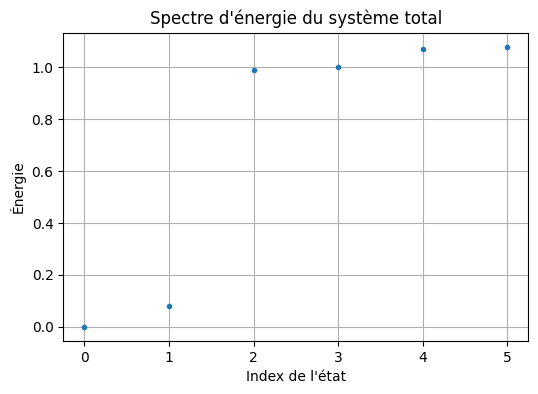

In [36]:
# 1. Hermitian verification
print("H_orb est hermitien :", H_orb.isherm)
print("H_spin_k est hermitien :", H_spin.isherm)
print("H_tot est hermitien :", H_tot.isherm)

# On calcule les valeurs propres (énergies)
energies = H_tot.eigenenergies()

# On affiche les 10 premières énergies
print("Les 10 plus basses énergies du système :")
print(energies[:10])

# Petit plot pour visualiser la densité d'états
plt.figure(figsize=(6,4))
plt.plot(energies, 'o', markersize=3)
plt.title("Spectre d'énergie du système total")
plt.ylabel("Énergie")
plt.xlabel("Index de l'état")
plt.grid(True)
plt.show()

Les 10 plus basses énergies du système :
[-0.98212851 -0.98005969  0.          0.08011887  0.08011887  0.08119383
  0.08119383  0.08433609  0.08433609  0.08932647]


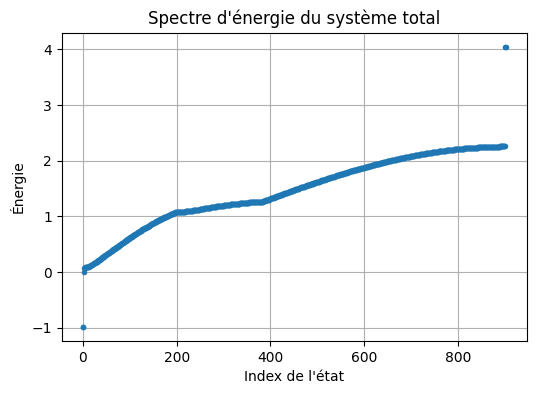

In [57]:
# On calcule les valeurs propres (énergies)
energies = H_tot.eigenenergies()

# On affiche les 10 premières énergies
print("Les 10 plus basses énergies du système :")
print(energies[:10])

# Petit plot pour visualiser la densité d'états
plt.figure(figsize=(6,4))
plt.plot(energies, 'o', markersize=3)
plt.title("Spectre d'énergie du système total")
plt.ylabel("Énergie")
plt.xlabel("Index de l'état")
plt.grid(True)
plt.show()

## Dissipation (Lindblad Operator)

## Density Matrix 

## Impulsion sequence

## Feynmann Diagram

## Dynamic calcul

## Fourier Transform

## Signal extraction

## 2D spectra plot